In [2]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product



%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [3]:
pre=100
post=100
session_path = '../data/co6/co6_10122023'
session = MPOptoClass(session_path, post=post)

love


# co6, 10/12/23

In [4]:
fs=1
pre=100

laser_bounds = copy.deepcopy(session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre

CFA_b, RFA_b = session.smoother(bounds=laser_bounds, sigma=10, binsize=fs, concat=False)
CFA_c, RFA_c = session.smoother(bounds=ctrl_bounds, sigma=10, binsize=fs, concat=False)

trial_length = CFA_b[0].shape[0]
num_trials = len(CFA_b)
num_ctrls = len(CFA_c)
num_neurons = CFA_b[0].shape[1]
num_climbing = np.sum(session.climbing_logical)

CFA_b = np.array(CFA_b)
RFA_b = np.array(RFA_b)
CFA_c = np.array(CFA_c)
RFA_c = np.array(RFA_c)

In [5]:
print(f'num CFA neurons: {session.num_CFA}')
print(f'num RFA neurons: {session.num_RFA}')
print(f'num stim trials: {num_trials} ({num_ctrls} ctrls)')
print(f'milliseconds climbing: {num_climbing}')

num CFA neurons: 238
num RFA neurons: 409
num stim trials: 71 (68 ctrls)
milliseconds climbing: 377017


In [6]:
highlaser_idx = np.squeeze(np.where(np.array(session.laser['laser_powers']) > 2.26))
start = laser_bounds[highlaser_idx[0],0]
end = laser_bounds[highlaser_idx[0],1]
laser_curve = session.laser['laser_ts'][start:end]
laser_curve = laser_curve[laser_curve>0.1]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


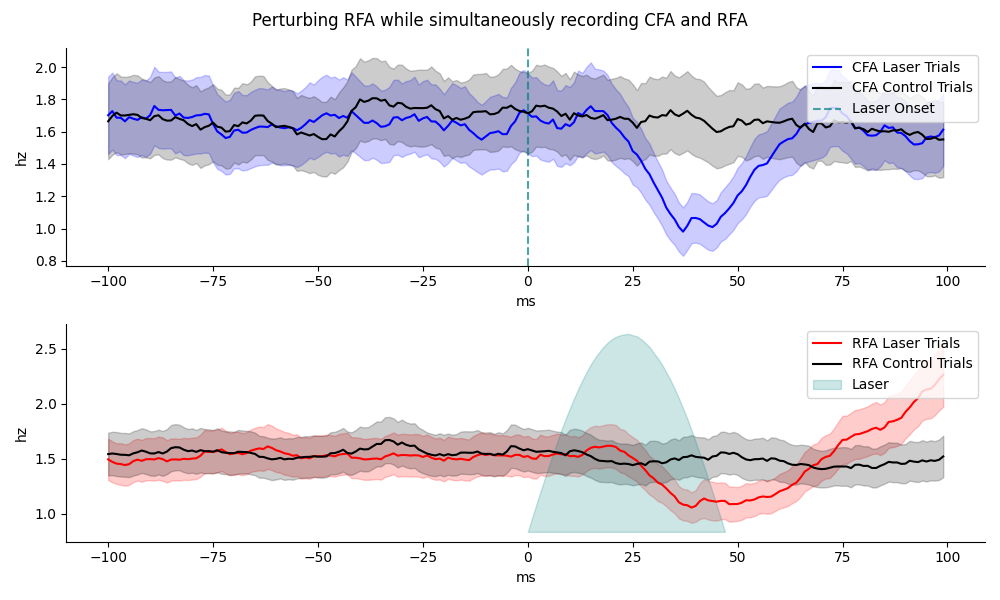

In [7]:
CFA_sts_avgavg = np.average(CFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_b, axis=0)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_b, axis=0)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_c, axis=0)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_c, axis=0)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre

fig1b, ax1b = plt.subplots(2, 1, figsize=(10,6))
ax1b[0].plot(x, CFA_sts_avgavg, color='blue', label='CFA Laser Trials')
ax1b[0].plot(x, CFA_ctrlsts_avgavg, color='black', label = 'CFA Control Trials')
ax1b[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1b[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
ax1b[0].axvline(0, color='teal', alpha=0.7, ls='--', label='Laser Onset')
ax1b[0].set_ylabel('hz')
ax1b[0].set_xlabel('ms')
ax1b[0].legend(loc=1)

ax1b[1].plot(x, RFA_sts_avgavg, color='red', label='RFA Laser Trials')
ax1b[1].plot(x, RFA_ctrlsts_avgavg, color='black', label='RFA Control Trials')
ax1b[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1b[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
rfa_ymin = ax1b[1].get_ylim()[0]
rfa_ymax = ax1b[1].get_ylim()[1]
rfa_laser = normalizeDataToRange(laser_curve, (rfa_ymin, rfa_ymax))
rfa_laser_x = np.arange(0,48)
ax1b[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2, label='Laser')
#rfa_ymin = ax1b[1].get_ylim()[0]
#rfa_ymax = ax1b[1].get_ylim()[1]
#rfa_laser = normalizeDataToRange(laser_curve, (rfa_ymin, rfa_ymax))
#rfa_laser_x = np.arange(0,4.8,.1)
#ax1b[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1b[1].legend(loc=1)
ax1b[1].set_xlabel('ms')
ax1b[1].set_ylabel('hz')

ax1b[0].spines['top'].set_visible(False)
ax1b[0].spines['right'].set_visible(False)
ax1b[1].spines['top'].set_visible(False)
ax1b[1].spines['right'].set_visible(False)
fig1b.suptitle('Perturbing RFA while simultaneously recording CFA and RFA')


fig1b.tight_layout()
#fig1b.savefig('../results/fig1.pdf')

# 2. lets get a sense of how stims affect predictions

In [17]:
num_PCs = 20
#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8)

omitTestLaserBounds = omitBoundInBounds(session.climbing_bounds, test_lasers)
omitAllLaserBounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)

(all_nlags_PCA, all_cut_PCA), all_PCObjs = session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=5, nlags=20, num_PCs=num_PCs)
all_cut_CFAPCA = all_cut_PCA[:, :num_PCs]

#(sall_nlags_PCA, nada), nada = session.format_nlags_PCA_smooth(bounds=omitAllLaserBounds, sigma=30, binsize=10, nlags=10, num_PCs=num_PCs)



(laser_nlags_PCA, laser_cut_PCA), laser_PCObjs = session.format_nlags_PCA(bounds=omitTestLaserBounds, binsize=5, nlags=20, num_PCs=num_PCs)

#(slaser_nlags_PCA, nada), nada = session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, sigma=30, binsize=10, nlags=10, num_PCs=num_PCs)

laser_cut_CFAPCA = laser_cut_PCA[:, :num_PCs]


In [18]:
print(all_cut_CFAPCA.shape)
print(laser_cut_CFAPCA.shape)

(71706, 20)
(73066, 20)


In [19]:
all_output = Ridge_kfolds_redo(all_nlags_PCA, all_cut_CFAPCA, alpha=2000, k=10)
laser_output = Ridge_kfolds_redo(laser_nlags_PCA, laser_cut_CFAPCA, alpha=2000, k=10)

10it [00:09,  1.09it/s]
10it [00:09,  1.06it/s]


climbing fit score: 0.09469577685081741
climbing test score: 0.07411050386871461
with stim fit score: 0.09469577685081741
with stim test score: 0.07411050386871461


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


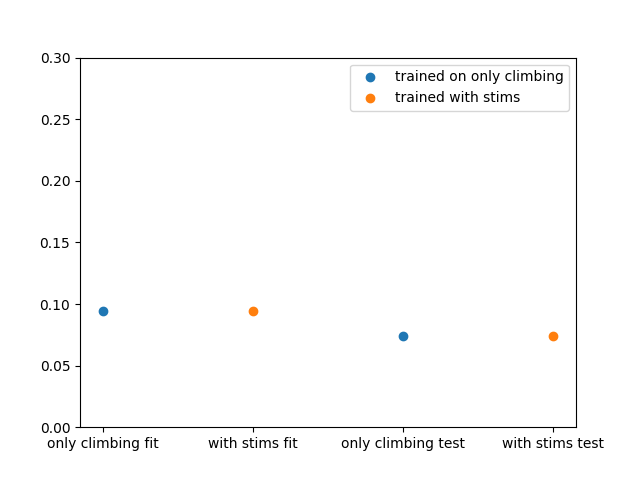

In [20]:
fitscore = all_output['fit_score']
testscore = all_output['test_score']
print(f'climbing fit score: {fitscore}')
print(f'climbing test score: {testscore}')
fig0, ax0 = plt.subplots()

stim_fitscore = laser_output['fit_score']
stim_testscore = laser_output['test_score']
print(f'with stim fit score: {fitscore}')
print(f'with stim test score: {testscore}')
ax0.scatter(['only climbing fit'], fitscore, color='tab:blue', label='trained on only climbing')
ax0.scatter(['with stims fit'], fitscore, color='tab:orange', label='trained with stims')
ax0.scatter(['only climbing test'], testscore, color='tab:blue')
ax0.scatter(['with stims test'], testscore, color='tab:orange')
ax0.set_ylim([0,.3])
ax0.legend()



In [21]:
alltest_nlags_PCA, alltest_cut_PCA = session.transformat(all_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=5, nlags=20)
alltest_cut_CFAPCA = alltest_cut_PCA[:, :num_PCs]

lasertest_nlags_PCA, lasertest_cut_PCA = session.transformat(laser_PCObjs, bounds=test_lasers, num_PCs = num_PCs, binsize=5, nlags=20)
lasertest_cut_CFAPCA = lasertest_cut_PCA[:, :num_PCs]

all: 0.07744783610306893
laser: 0.07884007739430006


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'testing on held out lasers')

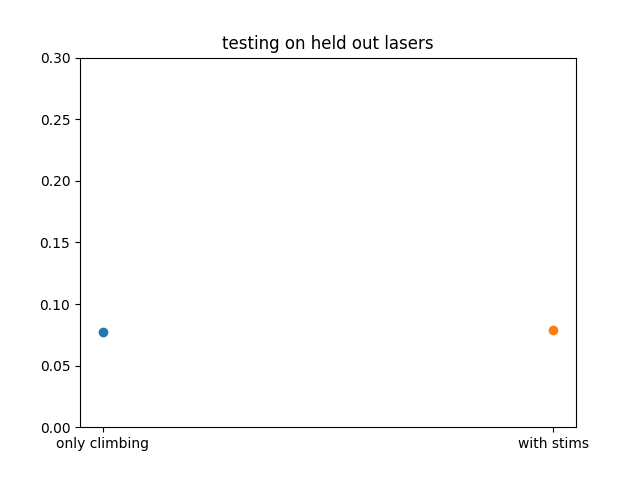

In [22]:
all_model = all_output['best_model']
laser_model = laser_output['best_model']

all_predic = all_model.predict(alltest_nlags_PCA)
all_predic = all_predic[:, :num_PCs]
laser_predic = laser_model.predict(lasertest_nlags_PCA)
laser_predic = laser_predic[:, :num_PCs]

all_r2 = weighted_r2(alltest_cut_CFAPCA, all_predic)
laser_r2 = weighted_r2(lasertest_cut_CFAPCA, laser_predic)

print(f'all: {all_r2}')
print(f'laser: {laser_r2}')
fig00, ax00 = plt.subplots()
ax00.scatter('only climbing', all_r2)
ax00.scatter('with stims', laser_r2)
ax00.set_ylim([0,.3])
ax00.set_title('testing on held out lasers')

In [14]:
all_CFA_weight, all_RFA_weight = session.weights_per_region_ridgeobject(all_model.coef_.T)
all_ratio = np.log10(all_CFA_weight/all_RFA_weight)
laser_CFA_weight, laser_RFA_weight = session.weights_per_region_ridgeobject(laser_model.coef_.T)
laser_ratio = np.log10(laser_CFA_weight/laser_RFA_weight)

fig, ax = plt.subplots()
ax.scatter([0,1],[all_ratio, laser_ratio])

IndexError: index 2380 is out of bounds for axis 0 with size 400

# smoothing inputs

In [23]:
(sall_nlags_PCA, nada), nada = session.format_nlags_PCA_smooth(bounds=omitAllLaserBounds, sigma=20, binsize=5, nlags=20, num_PCs=num_PCs)
(slaser_nlags_PCA, nada), nada = session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, sigma=20, binsize=5, nlags=20, num_PCs=num_PCs)
sall_output = Ridge_kfolds_redo(sall_nlags_PCA, all_cut_CFAPCA, alpha=2000, k=10)
slaser_output = Ridge_kfolds_redo(slaser_nlags_PCA, laser_cut_CFAPCA, alpha=2000, k=10)

10it [00:09,  1.08it/s]
10it [00:09,  1.06it/s]


climbing fit score: 0.07572234499103409
climbing test score: 0.07203753601069432
with stim fit score: 0.07572234499103409
with stim test score: 0.07203753601069432


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


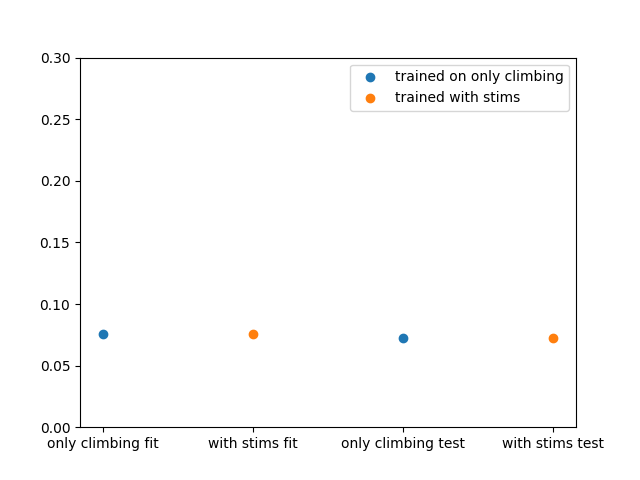

In [24]:
sfitscore =sall_output['fit_score']
stestscore = sall_output['test_score']
print(f'climbing fit score: {sfitscore}')
print(f'climbing test score: {stestscore}')
fig1, ax1 = plt.subplots()

sstim_fitscore = slaser_output['fit_score']
sstim_testscore = slaser_output['test_score']
print(f'with stim fit score: {sfitscore}')
print(f'with stim test score: {stestscore}')
ax1.scatter(['only climbing fit'], sfitscore, color='tab:blue', label='trained on only climbing')
ax1.scatter(['with stims fit'], sfitscore, color='tab:orange', label='trained with stims')
ax1.scatter(['only climbing test'], stestscore, color='tab:blue')
ax1.scatter(['with stims test'], stestscore, color='tab:orange')
ax1.set_ylim([0,.3])
ax1.legend()


In [ ]:
fig10, ax10=plt.subplots()

# smoothing everything but previous history

In [52]:
num_PCs=20
(s_nlags_PCA, cut_PCA), nada = session.format_nlags_PCA_smooth(bounds=session.climbing_bounds, sigma=100, binsize=10, nlags=3, num_PCs=num_PCs)
(b_nlags_PCA, b_cut_PCA), b_PCObjs = session.format_nlags_PCA(bounds = session.climbing_bounds, binsize=10, nlags=3, num_PCs=num_PCs)
b_cut_PCA = b_cut_PCA[:, :num_PCs]

In [53]:
b_nlags_PCA_train, b_nlags_PCA_test, s_nlags_PCA_train, s_nlags_PCA_test,b_cut_PCA_train, b_cut_PCA_test  = train_test_split(b_nlags_PCA, s_nlags_PCA, b_cut_PCA, train_size=.8)

In [54]:
h_list, r2, predics = smooth_other_features(b_nlags_PCA, s_nlags_PCA, b_cut_PCA, nlags=3, C=2000)

100%|████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 14.68it/s]


In [55]:
nada, binned_r2, predics2 = smooth_other_features(b_nlags_PCA, b_nlags_PCA, b_cut_PCA, nlags=3, C=2000)

100%|████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 14.88it/s]


In [56]:
s_nlags_PCA.shape

(37365, 120)

In [57]:
predics.shape

(20, 37365)

In [58]:
print(r2)
print(binned_r2)

0.09857791999679005
0.10784303537139642


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


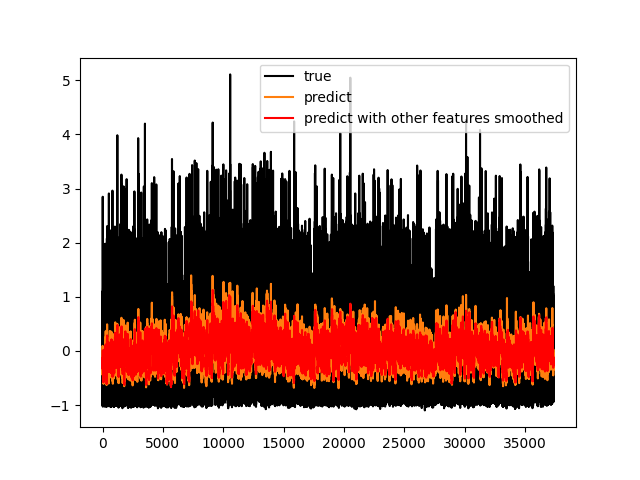

In [59]:
fig, ax = plt.subplots()

ax.plot(b_cut_PCA[:,0], color='black', label='true')
ax.plot(predics2.T[:,0], color='tab:orange', label='predict')
ax.plot(predics.T[:,0], color='red', label='predict with other features smoothed')
ax.legend()

In [22]:
predic = test_wiener_filter(

(401,)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


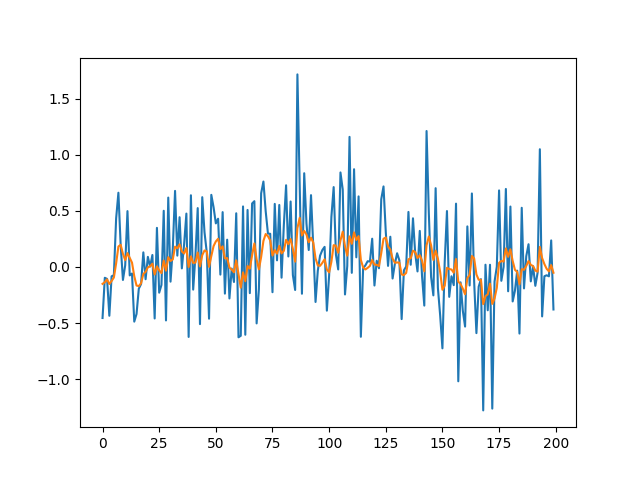

In [23]:
fig, ax =plt.subplots()
ax.plot(b_cut_PCA[:200,2])
ax.plot(cut_PCA[:200,2])
#ax.plot(all_cut_CFAPCA[:200,2])

In [112]:
r2

0.11468005587582526

# load sweep

In [47]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegs.pickle')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


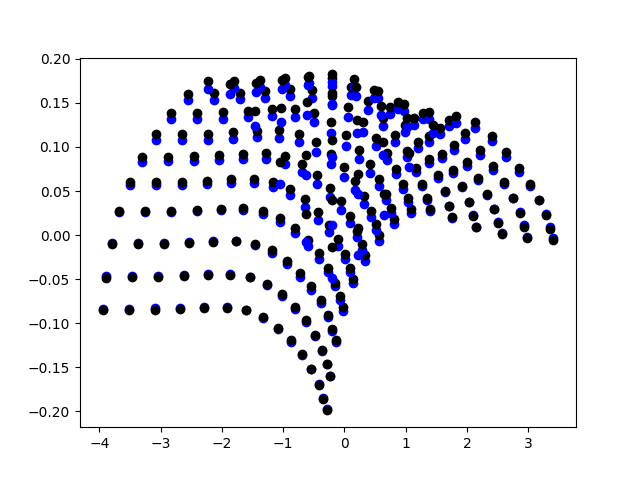

In [48]:
fig, ax = plt.subplots()
ratio_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []
for idx, o in enumerate(output):
    h = o[0]
    laser_score = o[1]
    ctrl_score = o[2]
    
    temp = session.weights_per_region(h)
    ratio = np.log10(temp[0]/temp[1])
    
    ratio_list.append(ratio)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    
    ax.scatter(ratio, o[1], color='blue')
    ax.scatter(ratio, o[2], color='black')
#ax.legend()

In [49]:
reg_terms = np.logspace(0,6,15)
reg_combos = list(product(reg_terms, reg_terms))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
ratio_list = np.array(ratio_list)

In [50]:
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

laser_score_keep = []
ctrl_score_keep = []
ratio_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(laser_score_list[indices])
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(ctrl_score_list[indices])
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


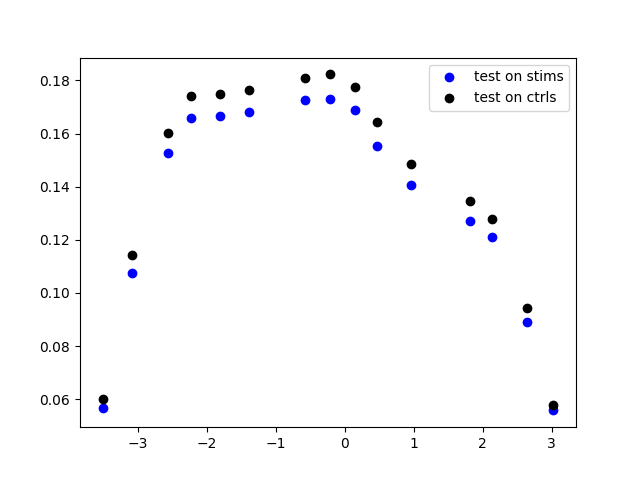

In [53]:
fig, ax = plt.subplots()
ax.scatter(ratio_keep, laser_score_keep, color='blue', label='test on stims')
ax.scatter(ratio_keep, ctrl_score_keep, color='black', label='test on ctrls')
ax.legend()